In [10]:
import pandas as pd

data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                      1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 0.5],
    'Marks': [20, 30, 35, 50, 55, 65, 70, 80, 85, 95,
               25, 32, 42, 55, 60, 68, 76, 82, 90, 15],
    'Sleep_Hours': [7, 6, 5, 4, 3, 2, 1, 0, 0, 0,
                    6.5, 5.5, 4.5, 3.5, 2.5, 1.5, 0.5, 0.25, 0.125, 8],
    'Play_Hours': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                   2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 1]
}
df = pd.DataFrame(data)
df.to_csv('student_scores.csv', index=False)
print("Dataset created and saved as 'student_scores.csv'")

Dataset created and saved as 'student_scores.csv'


In [12]:
print("Head of the dataset:")
print(df.head())

Head of the dataset:
   Hours_Studied  Marks  Sleep_Hours  Play_Hours
0            1.0     20          7.0         2.0
1            2.0     30          6.0         3.0
2            3.0     35          5.0         4.0
3            4.0     50          4.0         5.0
4            5.0     55          3.0         6.0


<b><h5>Actual task prediction starts: </h5></b>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
#Load the dataset
dataset = pd.read_csv('student_scores.csv')
print("Dataset shape:", dataset.shape)
print("Dataset loaded successfully.")
print(dataset.head())

Dataset shape: (20, 4)
Dataset loaded successfully.
   Hours_Studied  Marks  Sleep_Hours  Play_Hours
0            1.0     20          7.0         2.0
1            2.0     30          6.0         3.0
2            3.0     35          5.0         4.0
3            4.0     50          4.0         5.0
4            5.0     55          3.0         6.0


<b>Relation between hours studied and marks</b>

In [17]:
X = dataset[['Hours_Studied']]
y = dataset['Marks']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n Training samples: {len(X_train)}")
print(f" Testing samples: {len(X_test)}")


 Training samples: 16
 Testing samples: 4


In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
m = model.coef_[0]
c = model.intercept_
print(f"\n Slope (m): {m:.2f}")
print(f" Y-intercept (c): {c:.2f}")
print(f" Linear equation: Marks = {m:.2f} x Hours_Studied + {c:.2f}")


 Slope (m): 8.27
 Y-intercept (c): 13.18
 Linear equation: Marks = 8.27 x Hours_Studied + 13.18


In [24]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [29]:
print("*"*50)
print("                  Model Evaluation")
print("*"*50)
print(f" Mean Squared Error (MSE): {mse:.2f}")
print(f" Mean Absolute Error (MAE): {mae:.2f}")
print(f" R-squared (R2): {r2:.2f}")
print("*"*50)

**************************************************
                  Model Evaluation
**************************************************
 Mean Squared Error (MSE): 1.36
 Mean Absolute Error (MAE): 1.07
 R-squared (R2): 1.00
**************************************************


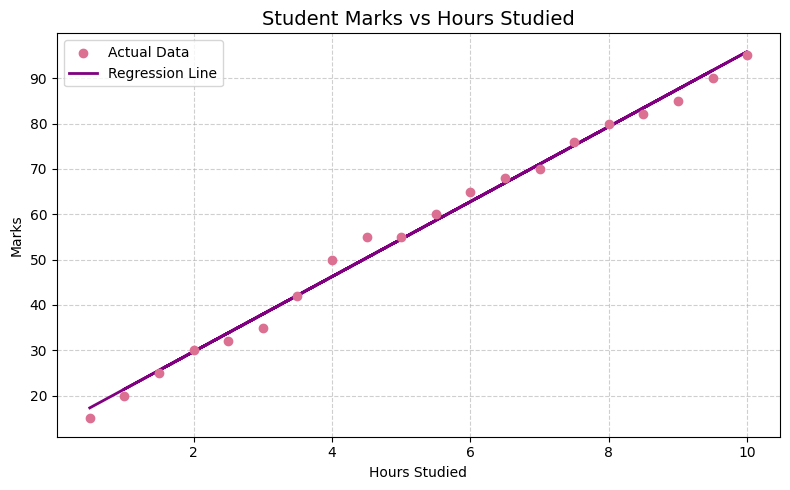

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='palevioletred', label='Actual Data', zorder=3)
plt.plot(X, model.predict(X), color='purple', linewidth=2, label='Regression Line')
plt.title('Student Marks vs Hours Studied', fontsize=14)
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('regression_plot.png')
plt.show()

In [39]:
#prediction with own inputs
def predict_marks(hours):
    result = model.predict([[hours]])[0]
    print(f"If you study {hours} hours → Predicted Marks: {result:.1f}")

predict_marks(3)
predict_marks(6)
predict_marks(9)

If you study 3 hours → Predicted Marks: 38.0
If you study 6 hours → Predicted Marks: 62.8
If you study 9 hours → Predicted Marks: 87.6


c:\Users\R Kapoor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\R Kapoor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\R Kapoor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<b>Relation between Sleep Hours and marks</b>

In [53]:
X = dataset[['Sleep_Hours']]
y = dataset['Marks']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n Training samples: {len(X_train)}")
print(f" Testing samples: {len(X_test)}")



 Training samples: 16
 Testing samples: 4


In [55]:
model = LinearRegression()
model.fit(X_train, y_train)
m = model.coef_[0]
c = model.intercept_
print(f"\n Slope (m): {m:.2f}")
print(f" Y-intercept (c): {c:.2f}")
print(f" Linear equation: Marks = {m:.2f} x Sleep_Hours + {c:.2f}")


 Slope (m): -9.24
 Y-intercept (c): 84.78
 Linear equation: Marks = -9.24 x Sleep_Hours + 84.78


In [57]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("*"*50)
print("            Model Evaluation (Sleep Hours)")
print("*"*50)
print(f"\n Mean Squared Error: {mse:.2f}")
print(f" Mean Absolute Error: {mae:.2f}")
print(f" R-squared (R2): {r2:.2f}")
print("*"*50)

**************************************************
            Model Evaluation (Sleep Hours)
**************************************************

 Mean Squared Error: 2.29
 Mean Absolute Error: 1.03
 R-squared (R2): 1.00
**************************************************


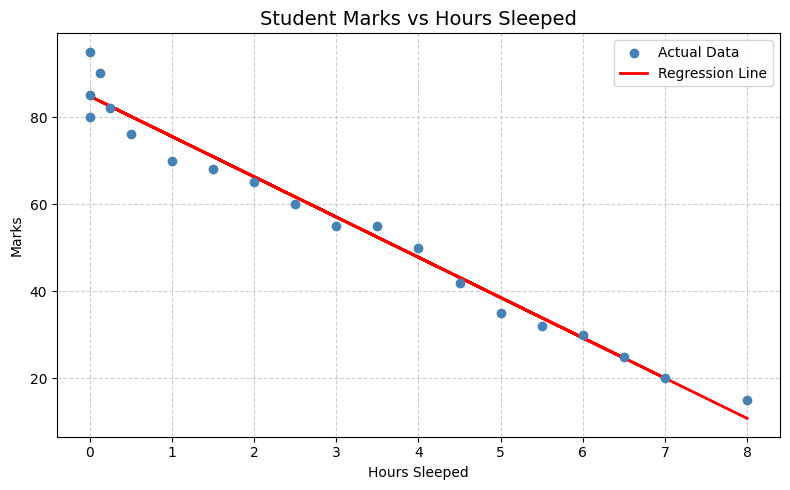

In [59]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', label='Actual Data', zorder=3)
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title('Student Marks vs Hours Sleeped', fontsize=14)
plt.xlabel('Hours Sleeped')
plt.ylabel('Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('regression_plot_sleep_hours.png')
plt.show()

In [60]:
X = dataset[['Hours_Studied', 'Sleep_Hours', 'Play_Hours']]
y = dataset['Marks']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n Training samples: {len(X_train)}")
print(f" Testing samples: {len(X_test)}")


 Training samples: 16
 Testing samples: 4


In [61]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
m = model.coef_
c = model.intercept_
print("\nCoefficients (m):", m)
print(f"Y-intercept (c): {c:.2f}")
print(f"Multiple Linear equation: Marks = {m[0]:.2f} x Hours_Studied + {m[1]:.2f} x Sleep_Hours + {m[2]:.2f} x Play_Hours + {c:.2f}")


Coefficients (m): [ 4.5617636  -1.8281942   2.08019972]
Y-intercept (c): 25.26
Multiple Linear equation: Marks = 4.56 x Hours_Studied + -1.83 x Sleep_Hours + 2.08 x Play_Hours + 25.26
